<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T1/CodigoDosAlunos/blob/main/TrabalhoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## credit_risk_dataset.csv

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregamento dos dados
df = pd.read_csv('credit_risk_dataset.csv')

# 1.1 Descritiva e Estatística
print(f"Tamanho da base: {df.shape[0]} linhas e {df.shape[1]} colunas.")
print("\nTipos de dados:\n", df.dtypes)
display(df.describe())

Tamanho da base: 32581 linhas e 12 colunas.

Tipos de dados:
 person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


/tmp/ipykernel_1298/97467209.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, ax=axes[1], palette='pastel')


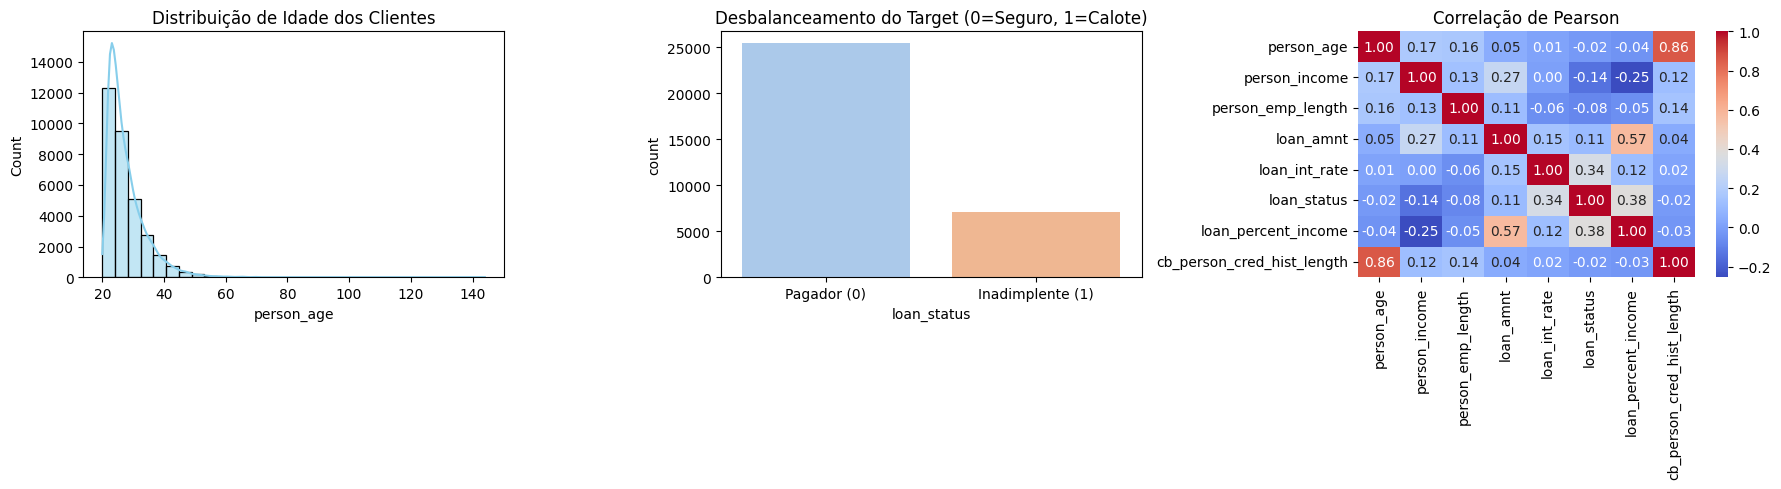

In [41]:
# 1.2 Visualizações Obrigatórias
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Distribuição de Idades (Histograma)
sns.histplot(df['person_age'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribuição de Idade dos Clientes')

# Gráfico 2: Desbalanceamento da Variável Alvo (Barras)
sns.countplot(x='loan_status', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Desbalanceamento do Target (0=Seguro, 1=Calote)')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Pagador (0)', 'Inadimplente (1)'])

# Gráfico 3: Mapa de Calor de Correlação (Apenas numéricas)
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2])
axes[2].set_title('Correlação de Pearson')

plt.tight_layout()
plt.show()

In [42]:
# 2.1 Remoção de Duplicadas
linhas_antes = df.shape[0]
df = df.drop_duplicates()
print(f"Linhas duplicadas removidas: {linhas_antes - df.shape[0]}")

# 2.2 Tratamento de Nulos
print("\nValores Nulos por Coluna:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Imputação com a MEDIANA
for col in ['person_emp_length', 'loan_int_rate']:
    if col in df.columns and df[col].isnull().sum() > 0:
        mediana = df[col].median()
        df[col] = df[col].fillna(mediana)

# 2.3 Tratamento de Outliers (Exemplo focado em Idade e Tempo de Emprego)
# Remoção de valores fisicamente impossíveis
df = df[(df['person_age'] <= 90) & (df['person_emp_length'] <= 60)]

Linhas duplicadas removidas: 165

Valores Nulos por Coluna:
 person_emp_length     887
loan_int_rate        3095
dtype: int64


In [43]:
# Criação da nova variável conforme regra de negócio
df['comprometimento_renda'] = (df['loan_amnt'] / df['person_income']) * 100
df = df.drop('loan_percent_income', axis=1)

In [44]:
# Verificando a criação
display(df.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,cb_person_default_on_file,cb_person_cred_hist_length,comprometimento_renda
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,N,2,10.416667
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,N,3,57.291667
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,N,2,53.435115
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,Y,4,64.338235
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,N,2,25.252525


In [45]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# 4.1 Encoding das Categóricas (One-Hot Encoding)
df_encoded = pd.get_dummies(df,columns=['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file'], drop_first=True)


In [46]:
df_encoded.head(2)

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,cb_person_cred_hist_length,comprometimento_renda,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
1,21,9600,5.0,1000,11.14,0,2,10.416667,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,3,57.291667,False,False,...,True,False,False,False,True,False,False,False,False,False


In [47]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# 4.2 Split de Dados
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Divisão 80/20 com estratificação exigida
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 4.3 Balanceamento com SMOTE (Apenas no Treino!)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# 4.4 Escalonamento Seguro para o KNN
scaler = StandardScaler()
# Fit e Transform apenas no Treino balanceado
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_bal), columns=X_train.columns)
# Apenas Transform no Teste para evitar Data Leakage
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Dados para a Árvore de Decisão (Mantém a escala original)
X_train_tree = X_train_bal.copy()
X_test_tree = X_test.copy()

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

print("="*65)
print("OTIMIZAÇÃO DO KNN (GridSearchCV)")
print("="*65)

# Parâmetros exigidos na documentação
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11, 15]}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)
grid_knn.fit(X_train_scaled, y_train_bal)

# Extraindo e exibindo os resultados para provar o overfitting
resultados_knn = pd.DataFrame(grid_knn.cv_results_)
for i in range(len(resultados_knn)):
    k = resultados_knn.loc[i, 'param_n_neighbors']
    acc_treino = resultados_knn.loc[i, 'mean_train_score']
    acc_val = resultados_knn.loc[i, 'mean_test_score']
    print(f"K={k} | Acc Treino: {acc_treino:.3f} | Acc Validação: {acc_val:.3f} | Gap: {acc_treino - acc_val:.3f}")

print(f"\nMelhor K encontrado: {grid_knn.best_params_['n_neighbors']}")


OTIMIZAÇÃO DO KNN (GridSearchCV)
K=3 | Acc Treino: 0.948 | Acc Validação: 0.903 | Gap: 0.045
K=5 | Acc Treino: 0.935 | Acc Validação: 0.905 | Gap: 0.030
K=7 | Acc Treino: 0.929 | Acc Validação: 0.906 | Gap: 0.023
K=9 | Acc Treino: 0.925 | Acc Validação: 0.906 | Gap: 0.019
K=11 | Acc Treino: 0.922 | Acc Validação: 0.905 | Gap: 0.017
K=15 | Acc Treino: 0.917 | Acc Validação: 0.901 | Gap: 0.016

Melhor K encontrado: 9


In [53]:

print("\n" + "="*65)
print("OTIMIZAÇÃO DA ÁRVORE DE DECISÃO (GridSearchCV)")
print("="*65)

param_grid_tree = {'max_depth': [3, 5, 7, 9, 11, 15]}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_tree,
    cv=5,
    scoring='recall',
    return_train_score=True
)
grid_tree.fit(X_train_tree, y_train_bal)

# Extraindo e exibindo os resultados
resultados_tree = pd.DataFrame(grid_tree.cv_results_)
for i in range(len(resultados_tree)):
    depth = resultados_tree.loc[i, 'param_max_depth']
    acc_treino = resultados_tree.loc[i, 'mean_train_score']
    acc_val = resultados_tree.loc[i, 'mean_test_score']
    print(f"Depth={depth} | Acc Treino: {acc_treino:.3f} | Acc Validação: {acc_val:.3f} | Gap: {acc_treino - acc_val:.3f}")

print(f"\nMelhor Profundidade encontrada: {grid_tree.best_params_['max_depth']}")


OTIMIZAÇÃO DA ÁRVORE DE DECISÃO (GridSearchCV)
Depth=3 | Acc Treino: 0.734 | Acc Validação: 0.732 | Gap: 0.002
Depth=5 | Acc Treino: 0.829 | Acc Validação: 0.817 | Gap: 0.012
Depth=7 | Acc Treino: 0.854 | Acc Validação: 0.846 | Gap: 0.008
Depth=9 | Acc Treino: 0.869 | Acc Validação: 0.855 | Gap: 0.013
Depth=11 | Acc Treino: 0.883 | Acc Validação: 0.864 | Gap: 0.019
Depth=15 | Acc Treino: 0.908 | Acc Validação: 0.877 | Gap: 0.031

Melhor Profundidade encontrada: 15


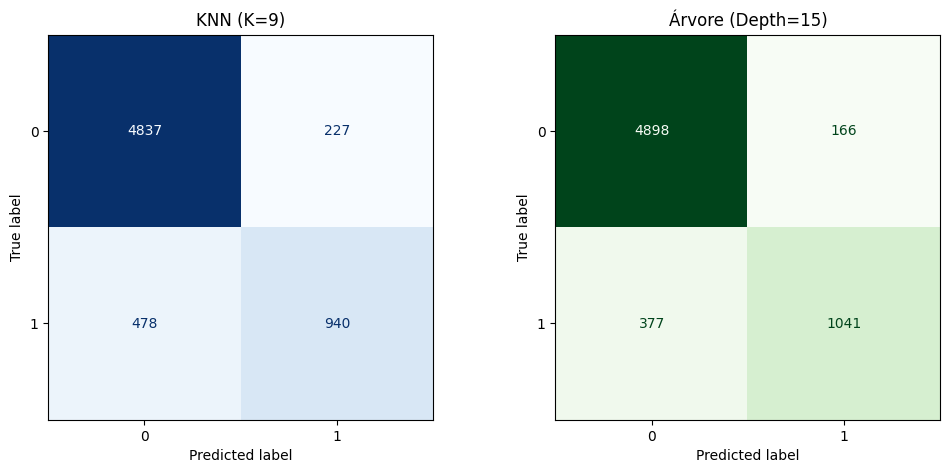


--- Relatório Final: Melhor KNN ---
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      5064
           1       0.81      0.66      0.73      1418

    accuracy                           0.89      6482
   macro avg       0.86      0.81      0.83      6482
weighted avg       0.89      0.89      0.89      6482


--- Relatório Final: Melhor Árvore de Decisão ---
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5064
           1       0.86      0.73      0.79      1418

    accuracy                           0.92      6482
   macro avg       0.90      0.85      0.87      6482
weighted avg       0.91      0.92      0.91      6482



In [52]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Extraindo os melhores modelos já treinados pelo GridSearch
best_knn = grid_knn.best_estimator_
best_tree = grid_tree.best_estimator_

# Previsões na base de Teste (Dados Inéditos)
pred_knn = best_knn.predict(X_test_scaled)
pred_tree = best_tree.predict(X_test_tree)

# Plot das Matrizes de Confusão
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_knn)).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'KNN (K={grid_knn.best_params_["n_neighbors"]})')

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_tree)).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'Árvore (Depth={grid_tree.best_params_["max_depth"]})')
plt.show()

print("\n--- Relatório Final: Melhor KNN ---")
print(classification_report(y_test, pred_knn))

print("\n--- Relatório Final: Melhor Árvore de Decisão ---")
print(classification_report(y_test, pred_tree))

##E Commerce Dataset.xlsx - E Comm.csv

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregamento dos dados
df = pd.read_csv('E Commerce Dataset.xlsx - E Comm.csv') # ou arquivo excel

# 1.1 Descritiva e Estatística
print(f"Tamanho da base: {df.shape[0]} linhas e {df.shape[1]} colunas.")
print("\nTipos de dados:\n", df.dtypes)
display(df.describe())

Tamanho da base: 5630 linhas e 20 colunas.

Tipos de dados:
 CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice            object
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode            object
Gender                          object
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                object
SatisfactionScore                int64
MaritalStatus                   object
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                   int64
dtype: object


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.221492
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.193869
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,146.000000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.000000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.000000
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,325.000000


/tmp/ipykernel_1298/612896682.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, ax=axes[1], palette='pastel')


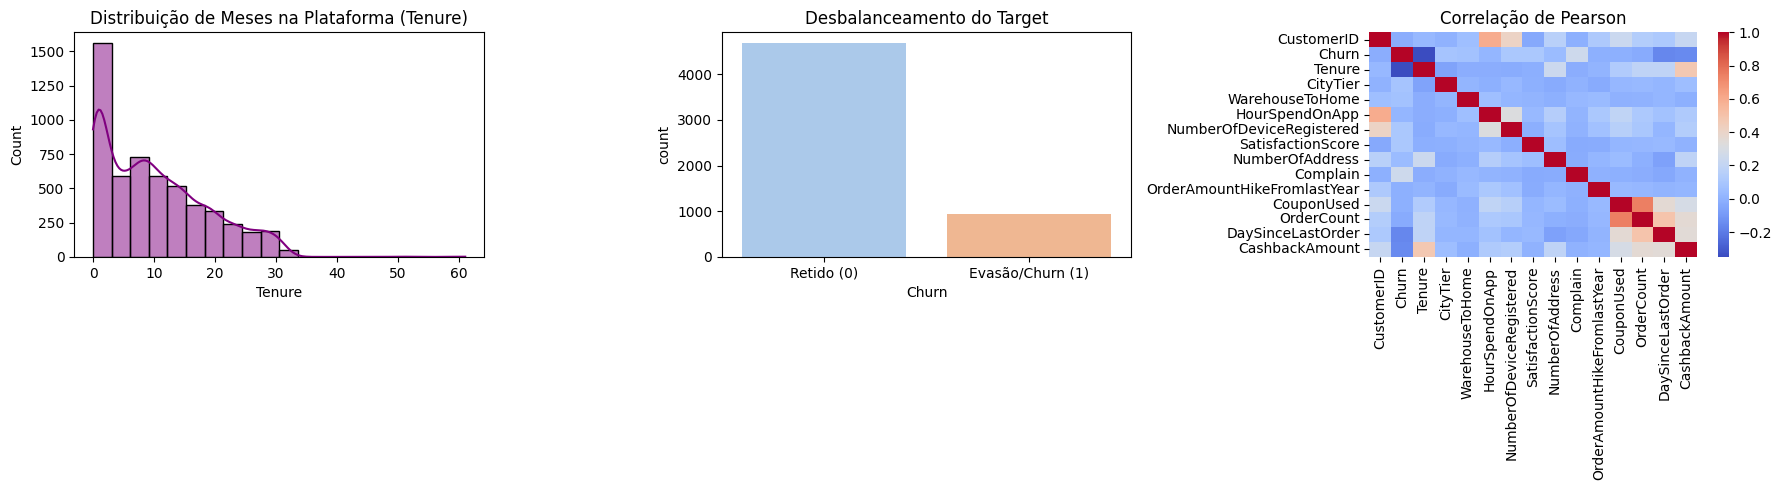

In [62]:
# 1.2 Visualizações Obrigatórias
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Distribuição de Tempo de Plataforma (Tenure)
sns.histplot(df['Tenure'], bins=20, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribuição de Meses na Plataforma (Tenure)')

# Gráfico 2: Desbalanceamento da Variável Alvo
sns.countplot(x='Churn', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Desbalanceamento do Target')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Retido (0)', 'Evasão/Churn (1)'])

# Gráfico 3: Mapa de Calor de Correlação (Apenas numéricas)
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', ax=axes[2]) # annot=False pois tem muitas colunas
axes[2].set_title('Correlação de Pearson')

plt.tight_layout()
plt.show()

In [63]:
# 2.1 Remoção de Duplicadas
linhas_antes = df.shape[0]
df = df.drop_duplicates()
print(f"Linhas duplicadas removidas: {linhas_antes - df.shape[0]}")

# 2.2 Tratamento de Nulos
print("\nValores Nulos por Coluna (Antes):\n", df.isnull().sum()[df.isnull().sum() > 0])

df['WarehouseToHome'] = (df.groupby('CityTier')['WarehouseToHome'].transform(lambda x: x.fillna(x.median())))

# Imputação com a MEDIANA para numéricas
colunas_num_nulas = ['Tenure', 'HourSpendOnApp', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder']
for col in colunas_num_nulas:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())


Linhas duplicadas removidas: 0

Valores Nulos por Coluna (Antes):
 Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64


In [64]:
df.head(10)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130
5,50006,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139
6,50007,1,9.0,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,121
7,50008,1,9.0,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,123
8,50009,1,13.0,Phone,3,9.0,E wallet,Male,3.0,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,127
9,50010,1,9.0,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,123


In [68]:
df['CashBackByOrder'] = np.where(df['OrderCount'] > 0, df['CashbackAmount'] / df['OrderCount'], 0)
# Criação da nova variável conforme regra de negócio (Base B)
#df['cashback_por_pedido'] = df['CashbackAmount'] / df['OrderCount']
# Dropando colunas que não agregam ao ML
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

display(df.head(10))

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,CashBackByOrder
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160,160.000000
1,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121,121.000000
2,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120,120.000000
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134,134.000000
4,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130,130.000000
5,1,0.0,Computer,1,22.0,Debit Card,Female,3.0,5,Mobile Phone,5,Single,2,1,22.0,4.0,6.0,7.0,139,23.166667
6,1,9.0,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,121,121.000000
7,1,9.0,Phone,1,6.0,CC,Male,3.0,3,Mobile,2,Divorced,3,1,16.0,2.0,2.0,0.0,123,61.500000
8,1,13.0,Phone,3,9.0,E wallet,Male,3.0,4,Mobile,3,Divorced,2,1,14.0,0.0,1.0,2.0,127,127.000000
9,1,9.0,Phone,1,31.0,Debit Card,Male,2.0,5,Mobile,3,Single,2,0,12.0,1.0,1.0,1.0,123,123.000000


In [71]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

# 4.1 Encoding das Categóricas (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=['PreferredLoginDevice','PreferredPaymentMode','Gender','PreferedOrderCat','MaritalStatus'], drop_first=True)

# 4.2 Split de Dados (Estratificado)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# 4.3 Balanceamento com SMOTE (Apenas no Treino)
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# 4.4 Escalonamento Seguro
scaler = StandardScaler()

# KNN exige escalonamento
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_bal), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Árvore não exige escalonamento
X_train_tree = X_train_bal.copy()
X_test_tree = X_test.copy()

In [73]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

print("="*65)
print("OTIMIZAÇÃO DO KNN (GridSearchCV)")
print("="*65)

param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11, 15,23,29,31,47,51]}
grid_knn = GridSearchCV(
    KNeighborsClassifier(), param_grid_knn, cv=5,
    scoring='accuracy', return_train_score=True
)
grid_knn.fit(X_train_scaled, y_train_bal)

resultados_knn = pd.DataFrame(grid_knn.cv_results_)
for i in range(len(resultados_knn)):
    k = resultados_knn.loc[i, 'param_n_neighbors']
    acc_tr = resultados_knn.loc[i, 'mean_train_score']
    acc_va = resultados_knn.loc[i, 'mean_test_score']
    print(f"K={k} | Acc Treino: {acc_tr:.3f} | Acc Validação: {acc_va:.3f} | Gap: {acc_tr - acc_va:.3f}")

print(f"\nMelhor K: {grid_knn.best_params_['n_neighbors']}")


print("\n" + "="*65)
print("OTIMIZAÇÃO DA ÁRVORE (GridSearchCV)")
print("="*65)

param_grid_tree = {'max_depth': [3, 5, 7, 9, 11 , 15]}
grid_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42), param_grid_tree, cv=5,
    scoring='accuracy', return_train_score=True
)
grid_tree.fit(X_train_tree, y_train_bal)

resultados_tree = pd.DataFrame(grid_tree.cv_results_)
for i in range(len(resultados_tree)):
    depth = resultados_tree.loc[i, 'param_max_depth']
    acc_tr = resultados_tree.loc[i, 'mean_train_score']
    acc_va = resultados_tree.loc[i, 'mean_test_score']
    print(f"Depth={depth} | Acc Treino: {acc_tr:.3f} | Acc Validação: {acc_va:.3f} | Gap: {acc_tr - acc_va:.3f}")

print(f"\nMelhor Profundidade: {grid_tree.best_params_['max_depth']}")

OTIMIZAÇÃO DO KNN (GridSearchCV)
K=3 | Acc Treino: 0.980 | Acc Validação: 0.936 | Gap: 0.044
K=5 | Acc Treino: 0.958 | Acc Validação: 0.920 | Gap: 0.038
K=7 | Acc Treino: 0.942 | Acc Validação: 0.911 | Gap: 0.031
K=9 | Acc Treino: 0.929 | Acc Validação: 0.904 | Gap: 0.025
K=11 | Acc Treino: 0.922 | Acc Validação: 0.901 | Gap: 0.021
K=15 | Acc Treino: 0.913 | Acc Validação: 0.894 | Gap: 0.019
K=23 | Acc Treino: 0.893 | Acc Validação: 0.880 | Gap: 0.013
K=29 | Acc Treino: 0.881 | Acc Validação: 0.868 | Gap: 0.013
K=31 | Acc Treino: 0.878 | Acc Validação: 0.866 | Gap: 0.012
K=47 | Acc Treino: 0.864 | Acc Validação: 0.854 | Gap: 0.009
K=51 | Acc Treino: 0.861 | Acc Validação: 0.851 | Gap: 0.010

Melhor K: 3

OTIMIZAÇÃO DA ÁRVORE (GridSearchCV)
Depth=3 | Acc Treino: 0.802 | Acc Validação: 0.791 | Gap: 0.011
Depth=5 | Acc Treino: 0.849 | Acc Validação: 0.832 | Gap: 0.016
Depth=7 | Acc Treino: 0.892 | Acc Validação: 0.867 | Gap: 0.025
Depth=9 | Acc Treino: 0.939 | Acc Validação: 0.898 | Gap: 

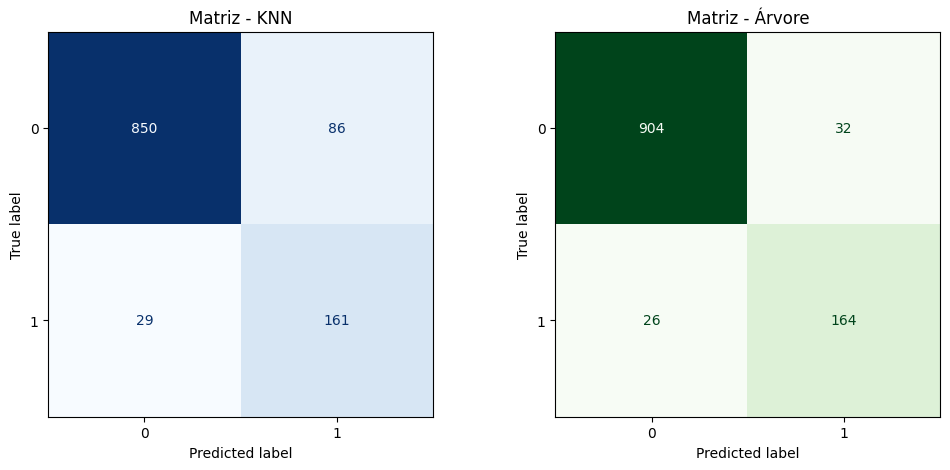


--- Relatório Final: Melhor KNN ---
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       936
           1       0.65      0.85      0.74       190

    accuracy                           0.90      1126
   macro avg       0.81      0.88      0.84      1126
weighted avg       0.91      0.90      0.90      1126


--- Relatório Final: Melhor Árvore de Decisão ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       936
           1       0.84      0.86      0.85       190

    accuracy                           0.95      1126
   macro avg       0.90      0.91      0.91      1126
weighted avg       0.95      0.95      0.95      1126



In [15]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

best_knn = grid_knn.best_estimator_
best_tree = grid_tree.best_estimator_

pred_knn = best_knn.predict(X_test_scaled)
pred_tree = best_tree.predict(X_test_tree)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_knn)).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz - KNN')

ConfusionMatrixDisplay(confusion_matrix(y_test, pred_tree)).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Matriz - Árvore')
plt.show()

print("\n--- Relatório Final: Melhor KNN ---")
print(classification_report(y_test, pred_knn))

print("\n--- Relatório Final: Melhor Árvore de Decisão ---")
print(classification_report(y_test, pred_tree))

## Gradient Boosting com XGBoost

BÔNUS: OTIMIZAÇÃO COM XGBOOST (GridSearchCV)
Análise de Overfitting (Gap):

Depth=3 | LR=0.05 | Trees=50 -> Acc Treino: 0.854 | Acc Val: 0.842 | Gap: 0.011
Depth=3 | LR=0.05 | Trees=100 -> Acc Treino: 0.897 | Acc Val: 0.879 | Gap: 0.018
Depth=5 | LR=0.05 | Trees=50 -> Acc Treino: 0.910 | Acc Val: 0.888 | Gap: 0.022
Depth=5 | LR=0.05 | Trees=100 -> Acc Treino: 0.950 | Acc Val: 0.919 | Gap: 0.031
Depth=3 | LR=0.1 | Trees=50 -> Acc Treino: 0.899 | Acc Val: 0.883 | Gap: 0.017
Depth=3 | LR=0.1 | Trees=100 -> Acc Treino: 0.934 | Acc Val: 0.907 | Gap: 0.027
Depth=5 | LR=0.1 | Trees=50 -> Acc Treino: 0.948 | Acc Val: 0.919 | Gap: 0.030
Depth=5 | LR=0.1 | Trees=100 -> Acc Treino: 0.977 | Acc Val: 0.939 | Gap: 0.038

Melhores Hiperparâmetros do XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


<Figure size 600x500 with 0 Axes>

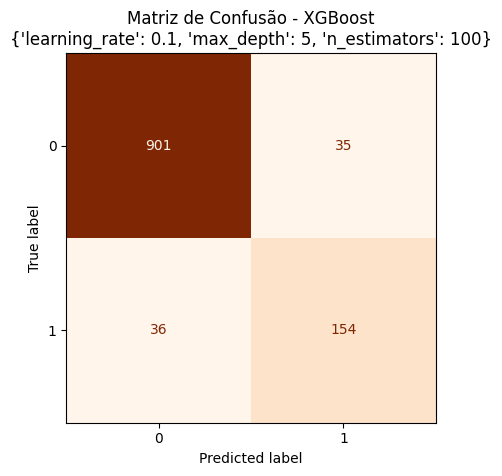


--- Relatório Final: Melhor XGBoost ---
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       936
           1       0.81      0.81      0.81       190

    accuracy                           0.94      1126
   macro avg       0.89      0.89      0.89      1126
weighted avg       0.94      0.94      0.94      1126



In [16]:
!pip install xgboost -q
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# =====================================================================
# BÔNUS: TREINAMENTO E OTIMIZAÇÃO COM XGBOOST (Gradient Boosting)
# =====================================================================
print("="*65)
print("BÔNUS: OTIMIZAÇÃO COM XGBOOST (GridSearchCV)")
print("="*65)

# O XGBoost possui hiperparâmetros diferentes da Árvore Clássica.
# Além da profundidade (max_depth), controlamos a taxa de aprendizado (learning_rate)
# e a quantidade de árvores (n_estimators).
param_grid_xgb = {
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [50, 100]
}

# Instanciando o modelo
# random_state=42 para reprodutibilidade
xgb_model = XGBClassifier(random_state=42)

# GridSearch configurado exatamente como ensinado (return_train_score=True)
grid_xgb = GridSearchCV(
    xgb_model,
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    return_train_score=True
)

# Treinamento utilizando os dados da Fase 4 (Balanceados, sem scaler)
# Nota: Assumimos que X_train_tree, y_train_bal, X_test_tree e y_test já existem na memória.
grid_xgb.fit(X_train_tree, y_train_bal)

# Extraindo os resultados para análise de Overfitting
resultados_xgb = pd.DataFrame(grid_xgb.cv_results_)

print("Análise de Overfitting (Gap):\n")
for i in range(len(resultados_xgb)):
    depth = resultados_xgb.loc[i, 'param_max_depth']
    lr = resultados_xgb.loc[i, 'param_learning_rate']
    n_est = resultados_xgb.loc[i, 'param_n_estimators']

    acc_treino = resultados_xgb.loc[i, 'mean_train_score']
    acc_val = resultados_xgb.loc[i, 'mean_test_score']
    gap = acc_treino - acc_val

    print(f"Depth={depth} | LR={lr} | Trees={n_est} -> Acc Treino: {acc_treino:.3f} | Acc Val: {acc_val:.3f} | Gap: {gap:.3f}")

print(f"\nMelhores Hiperparâmetros do XGBoost: {grid_xgb.best_params_}")

# =====================================================================
# AVALIAÇÃO FINAL DO XGBOOST
# =====================================================================
# Extraindo o melhor modelo
best_xgb = grid_xgb.best_estimator_

# Previsões na base de Teste
pred_xgb = best_xgb.predict(X_test_tree)

# Visualização da Matriz de Confusão
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_xgb)).plot(cmap='Oranges', colorbar=False)
plt.title(f'Matriz de Confusão - XGBoost\n{grid_xgb.best_params_}')
plt.show()

# Relatório de Classificação
print("\n--- Relatório Final: Melhor XGBoost ---")
print(classification_report(y_test, pred_xgb))